# Этап 4: Поведенческая кластеризация и поиск аномалий (Machine Learning) 

## Описание файла
Заключительный этап практической части работы. Применение методов машинного обучения (Machine Learning) без учителя для классификации участников блокчейна по их финансовому поведению.

**Используемые методы:**
1. **Масштабирование данных:** `StandardScaler` для изометрии многомерного евклидова пространства.
2. **Алгоритм K-Means:** Базовая центроидная модель кластеризации (Baseline).
3. **Алгоритм DBSCAN:** Продвинутая модель кластеризации на основе плотности, устойчивая к степенному распределению (Power Law) блокчейн-данных. Используется для задачи обнаружения аномалий (Anomaly Detection).
4. **Метод главных компонент (PCA):** Снижение размерности пространства до 2D для визуализации результатов.

**Цель:** Идентификация инфраструктурных узлов (бирж, пулов, сервисов-миксеров) среди общей массы пользователей на основе выявленных математических выбросов (шума).

**Входные данные:** `../data/entity_features.csv`

1. Загрузка собранных признаков...
2. Масштабирование данных в евклидовом пространстве...
3. Обучение модели K-Means (Поиск центроидов)...
4. Обучение модели DBSCAN (Поиск плотных облаков)...


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


5. Снижение размерности (PCA) для 2D визуализации...
6. Отрисовка сравнительных графиков...


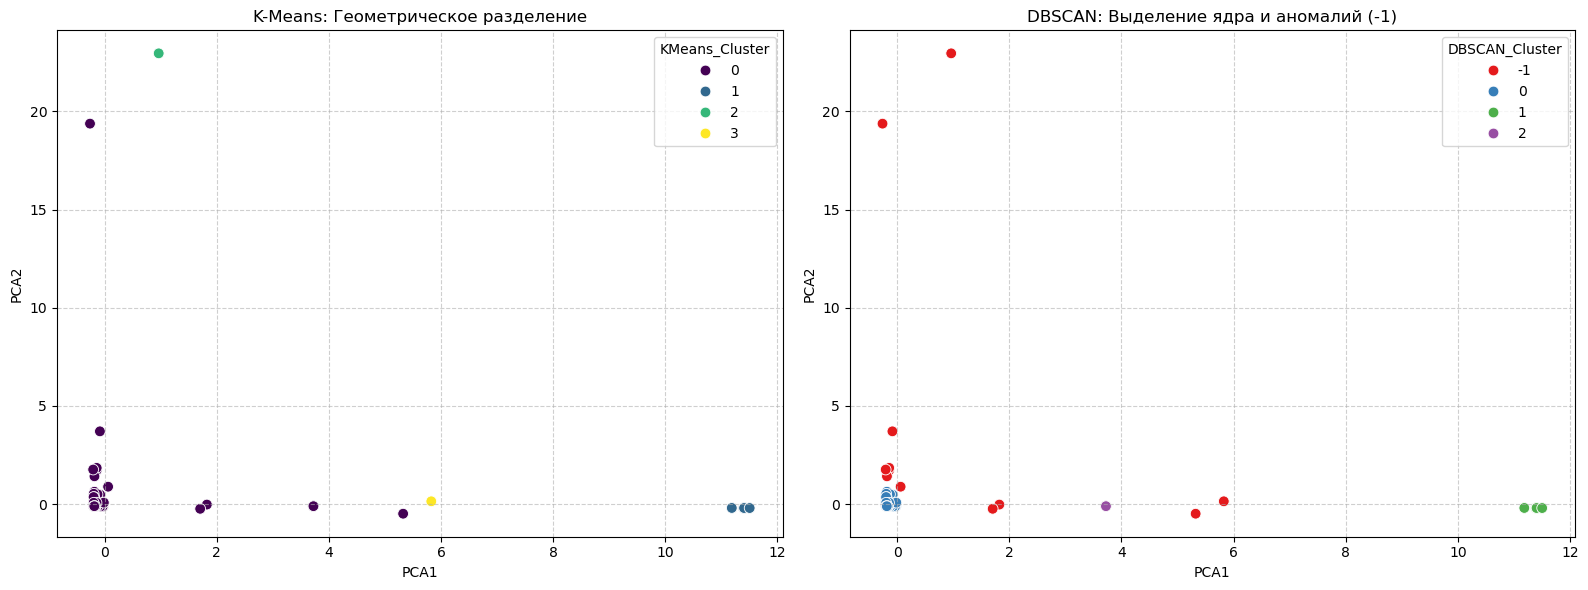


=== Распределение по группам (K-Means) ===
KMeans_Cluster
0    742
1     10
2      1
3      1
Name: count, dtype: int64

=== Распределение по группам (DBSCAN) ===
Внимание: Кластер '-1' — это аномалии (киты/биржи)!
DBSCAN_Cluster
 0    729
-1     12
 1     10
 2      3
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

def run_behavioral_clustering(csv_path):
    print("1. Загрузка собранных признаков...")
    df = pd.read_csv(csv_path)
    
    features = ['Tx_Count', 'Address_Count', 'Total_Received', 'Total_Sent', 'Balance']
    X = df[features]
    
    print("2. Масштабирование данных в евклидовом пространстве...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print("3. Обучение модели K-Means (Поиск центроидов)...")
    kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
    df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
    
    print("4. Обучение модели DBSCAN (Поиск плотных облаков)...")
    dbscan = DBSCAN(eps=0.5, min_samples=3)
    df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
    
    print("5. Снижение размерности (PCA) для 2D визуализации...")
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    df['PCA1'] = components[:, 0]
    df['PCA2'] = components[:, 1]
    
    print("6. Отрисовка сравнительных графиков...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    #K-Means
    sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans_Cluster', 
                    palette='viridis', ax=axes[0], s=60)
    axes[0].set_title('K-Means: Геометрическое разделение')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    #DBSCAN
    sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', 
                    palette='Set1', ax=axes[1], s=60)
    axes[1].set_title('DBSCAN: Выделение ядра и аномалий (-1)')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    return df

if __name__ == "__main__":
    df_results = run_behavioral_clustering("entity_features.csv")
    
    print("\n=== Распределение по группам (K-Means) ===")
    print(df_results['KMeans_Cluster'].value_counts())
    
    print("\n=== Распределение по группам (DBSCAN) ===")
    print("Внимание: Кластер '-1' — это аномалии (киты/биржи)!")
    print(df_results['DBSCAN_Cluster'].value_counts())

In [2]:
anomalies = df_results[df_results['DBSCAN_Cluster'] == -1]

anomalies = anomalies.sort_values(by='Tx_Count', ascending=False)

print("=== ДОСЬЕ НА 12 'КИТОВ' (АНОМАЛИИ DBSCAN) ===")
print(anomalies[['Entity_ID', 'Tx_Count', 'Address_Count', 'Total_Received', 'Total_Sent', 'Balance']])

=== ДОСЬЕ НА 12 'КИТОВ' (АНОМАЛИИ DBSCAN) ===
       Entity_ID  Tx_Count  Address_Count  Total_Received    Total_Sent  \
0     Cluster_99       382             73     1532.480598   1530.953268   
1      Cluster_9        78              1        1.458251      1.433140   
2     Cluster_14        38              1        0.829862      1.162296   
3      Cluster_3        31              9       28.990979     32.914631   
4     Cluster_21        15            323        1.370012     30.302013   
8     Cluster_15         7             22       16.030240     37.023514   
65    Cluster_73         2             17        0.000000   1221.230841   
198  Cluster_108         1              1        0.000000   9466.225179   
360  Cluster_114         1              1        0.000000  28238.254415   
594  Cluster_647         1              1     9446.881762      0.000000   
613  Cluster_660         1              1    27453.198576      0.000000   
743   Cluster_77         1             33        0.000